# 04 · DPO 偏好对齐

> 对应 JD 关键词：**DPO、偏好优化、对齐**。这是 T5 项目**完全没有**的一环，也是本升级版最大的增量。

## DPO 在做什么
- RLHF 要先训"奖励模型"再用强化学习，链路长、不稳。
- **DPO** 跳过奖励模型，直接用 (chosen, rejected) 偏好对训练：**抬高 chosen 概率、压低 rejected 概率**。
- `beta` 控制"对齐强度 vs 不偏离原模型"的平衡。


In [1]:
import os, json, sys   # os=文件/路径操作, json=读写json数据, sys=系统相关
import torch           # PyTorch：深度学习框架(模型和张量都靠它)

# 自动找到项目根目录（notebooks 文件夹的上一级）
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA = os.path.join(ROOT, "data")      # data 目录完整路径
OUT  = os.path.join(ROOT, "outputs")   # outputs 目录完整路径
os.makedirs(OUT, exist_ok=True)        # 新建 outputs 目录；exist_ok=True=已存在也不报错

# 选计算设备：苹果芯片用 mps，英伟达显卡用 cuda，都没有就用 cpu
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT  :", ROOT)
print("DEVICE:", DEVICE)

ROOT  : /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa
DEVICE: mps


In [2]:
# 【配置区】------------------------------------------------------
run_mode   = "smoke"
SFT_MERGED = os.path.join(OUT, "sft_merged")     # 03 的产物，DPO 的起点
DPO_OUT    = os.path.join(OUT, "dpo_lora")
DPO_MERGED = os.path.join(OUT, "dpo_merged")     # DPO 合并后的最终模型
EPOCHS     = 1 if run_mode == "smoke" else 3
BETA       = 0.1                                  # 关键超参：越大越听话于偏好、越小越保守
assert os.path.exists(SFT_MERGED), "请先跑完 03 生成 sft_merged"   # assert 条件,提示：不成立就报错

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, PeftModel
from trl import DPOTrainer, DPOConfig
from datasets import load_dataset

tokenizer = AutoTokenizer.from_pretrained(SFT_MERGED)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(SFT_MERGED, torch_dtype=torch.float32).to(DEVICE)  # 从SFT模型继续

lora_cfg = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05,
                      target_modules="all-linear", task_type="CAUSAL_LM")
dpo_ds = load_dataset("json", data_files=os.path.join(DATA, "dpo_train.json"), split="train")   # 加载偏好数据
print("DPO 偏好对:", len(dpo_ds), "| 字段:", dpo_ds.column_names)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DPO 偏好对: 600 | 字段: ['prompt', 'chosen', 'rejected']


In [5]:
dpo_args = DPOConfig(
    output_dir=DPO_OUT,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,                 # DPO 学习率一般比 SFT 更小
    beta=BETA,
    logging_steps=2,
    save_strategy="no",
    max_length=1280,                    # 总长上限（trl 1.6 已移除 max_prompt_length，删掉即可）
    bf16=False, fp16=False,
    report_to="none",
)
trainer = DPOTrainer(
    model=model, ref_model=None,        # ref_model=参考模型；用peft时trl自动用合并前基准，无需手动给
    args=dpo_args,
    train_dataset=dpo_ds,               # prompt/chosen/rejected 格式，trl 自动处理
    processing_class=tokenizer,
    peft_config=lora_cfg,
)
trainer.train()
trainer.save_model(DPO_OUT)
print("DPO 适配器已保存:", DPO_OUT)

Tokenizing train dataset:   0%|          | 0/600 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/yunye/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
2,0.692329
4,0.614117
6,0.573404
8,0.549311
10,0.527397
12,0.521442
14,0.405205
16,0.493151
18,0.524962
20,0.366769


DPO 适配器已保存: /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa/outputs/dpo_lora


In [8]:
accs = [x["rewards/accuracies"] for x in trainer.state.log_history if "rewards/accuracies" in x]
print("rewards/accuracies 前5个:", [round(a,3) for a in accs[:5]])
print("后5个:", [round(a,3) for a in accs[-5:]])

rewards/accuracies 前5个: [0.688, 0.812, 0.75, 0.812, 0.75]
后5个: [1.0, 1.0, 0.938, 1.0, 1.0]


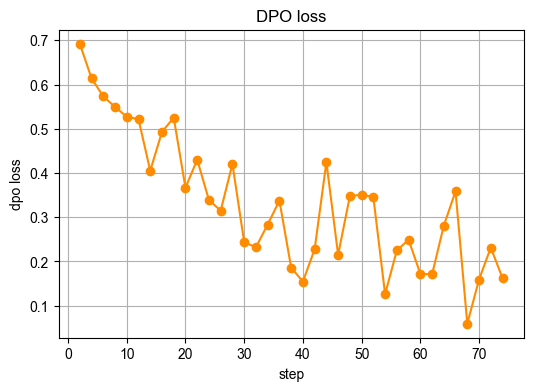

In [6]:
# ---- loss 曲线 ----
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "Heiti SC"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
logs = trainer.state.log_history
steps = [x["step"] for x in logs if "loss" in x]; loss = [x["loss"] for x in logs if "loss" in x]
os.makedirs(os.path.join(OUT, "figures"), exist_ok=True)
plt.figure(figsize=(6,4)); plt.plot(steps, loss, marker="o", color="darkorange")
plt.xlabel("step"); plt.ylabel("dpo loss"); plt.title("DPO loss"); plt.grid(True)
plt.savefig(os.path.join(OUT, "figures", "dpo_loss.png"), dpi=120, bbox_inches="tight"); plt.show()

In [7]:
# ---- 合并导出 SFT+DPO 最终模型 ----
base = AutoModelForCausalLM.from_pretrained(SFT_MERGED, torch_dtype=torch.float32)  # 以SFT模型为底
merged = PeftModel.from_pretrained(base, DPO_OUT).merge_and_unload()  # 装DPO补丁并合并
merged.save_pretrained(DPO_MERGED); tokenizer.save_pretrained(DPO_MERGED)
print("最终模型(SFT+DPO)已保存:", DPO_MERGED)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

最终模型(SFT+DPO)已保存: /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa/outputs/dpo_merged
